<a href="https://colab.research.google.com/github/AnanthSundarrajan/price-of-car/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

The core business challenge is to determine the main factors influencing used car prices. This can be conceptualized as a supervised machine learning regression task. Our objective is to develop a predictive model that estimates a used car's price using a variety of features, including its make, model, year, mileage, condition, and other pertinent characteristics. The model's effectiveness will be measured by how accurately it can forecast car prices and pinpoint the most significant features that drive those prices.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [174]:
import pandas as pd

# Load the vehicles.csv file into a pandas DataFrame named df
df = pd.read_csv('vehicles.csv')

#Generate basic data interpretation
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics (including all columns):")
print(df.describe(include='all'))

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows of the DataFrame:
           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  

In [175]:
#Identify the missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Column Name': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage': missing_percentage.values
})

missing_info = missing_info[missing_info['Missing Values'] > 0]
missing_info = missing_info.sort_values(by='Missing Percentage', ascending=False).reset_index(drop=True)

print("Missing Values Analysis:")
print(missing_info)

Missing Values Analysis:
     Column Name  Missing Values  Missing Percentage
0           size          306361           71.767476
1      cylinders          177678           41.622470
2      condition          174104           40.785232
3            VIN          161042           37.725356
4          drive          130567           30.586347
5    paint_color          130203           30.501078
6           type           92858           21.752717
7   manufacturer           17646            4.133714
8   title_status            8242            1.930753
9          model            5277            1.236179
10      odometer            4400            1.030735
11          fuel            3013            0.705819
12  transmission            2556            0.598763
13          year            1205            0.282281


In [176]:
#Identify duplicate rows

duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

Number of duplicate rows found: 0


In [177]:
# Identify the type of information in each column
print("Current DataFrame Information before type conversion:")
df.info()

Current DataFrame Information before type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 

In [178]:
# Display all the unique values in each of the columns
print("\nUnique values for each column and their counts:")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(df[col].value_counts())


Unique values for each column and their counts:

Column: id
Number of unique values: 426880
id
7301949724    1
7301950980    1
7301951550    1
7301951544    1
7301952155    1
             ..
7210384030    1
7222270760    1
7221797935    1
7218891961    1
7222695916    1
Name: count, Length: 426880, dtype: int64

Column: region
Number of unique values: 404
region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64

Column: price
Number of unique values: 15655
price
0         32895
6995       3169
7995       3129
9995       2867
8995       2837
          ...  
118300        1
19782         1
16290         1
12915         1
36343         1
Name: count, Le

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

Step 1: Cleaning Data Set

Step 1.1 - Drop Cols
- 'VIN' and 'Size' as they have the highest percentage of missing data.
- 'ID' column as it does not provide any additional info
- 'Region' as this data is captured in the 'State' Col
- 'model' as there are ~30K unique variables and most of this information is captured in the 'manufacturer' col.

In [179]:
#Drop the columns
df_cleaned = df.drop(columns=['size', 'VIN', 'id','region', 'model'])


Step 1.2 - Categorial Cols (cylinders, condition, drive, paint_color, type, manufacturer, title_status, fuel, and transmission) - Replace missing values with 'unknown' to retain information in other columns

In [180]:
#Clean categorial cols
categorical_cols_to_impute = [
    'cylinders', 'condition', 'drive', 'paint_color', 'type',
    'manufacturer', 'title_status', 'fuel', 'transmission'
]

for col in categorical_cols_to_impute:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna('unknown')

Step 1. 3 - Numerical Cols (Odometer & Year) - Replace the missing values with the column median.

In [181]:
#Clean numerical cols
for col in ['odometer', 'year']:
    if col in df_cleaned.columns:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

Step 1.4 - Convert cols "Year" and "Odometer" to integers for easier processing

In [182]:
#Step 1.4 - Convert 'Year' and 'Odometer' to integers
df_cleaned['odometer'] = df_cleaned['odometer'].astype('int64')
df_cleaned['year'] = df_cleaned['year'].astype('int64')

Step 1.5 - Remove rows where the value is "Zero" in the price column

In [183]:
#Step 1.5 - Remove rows where the value of price is zero

original_rows_df_cleaned = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['price'] != 0].copy()
print(f"Rows in df_cleaned before removing price = 0: {original_rows_df_cleaned}")
print(f"Rows in df_cleaned after removing price = 0: {len(df_cleaned)}")

# Initialize df_cleaned_final for subsequent steps
df_cleaned_final = df_cleaned.copy()

Rows in df_cleaned before removing price = 0: 426880
Rows in df_cleaned after removing price = 0: 393985


Step 2 - Outlier Analysis

In [184]:
#Step 2.1 - Define a function to remove outlier
def remove_outliers_iqr(df, column):
    original_rows = len(df)

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    rows_removed = original_rows - len(df_filtered)
    print(f"Removed {rows_removed} rows from column '{column}' due to outliers.")

    return df_filtered

In [185]:
#Step 2.2 - Apply the outlier removal function to 'price', 'odometer', and 'year'
initial_rows = len(df_cleaned_final)

# Apply outlier removal to 'price' column
df_cleaned_final = remove_outliers_iqr(df_cleaned_final, 'price')

# Apply outlier removal to 'odometer' column
df_cleaned_final = remove_outliers_iqr(df_cleaned_final, 'odometer')

# Apply outlier removal to 'year' column
df_cleaned_final = remove_outliers_iqr(df_cleaned_final, 'year')

total_rows_removed = initial_rows - len(df_cleaned_final)
print(f"\nTotal rows removed across all specified columns: {total_rows_removed}")

Removed 7779 rows from column 'price' due to outliers.
Removed 3785 rows from column 'odometer' due to outliers.
Removed 14638 rows from column 'year' due to outliers.

Total rows removed across all specified columns: 26202


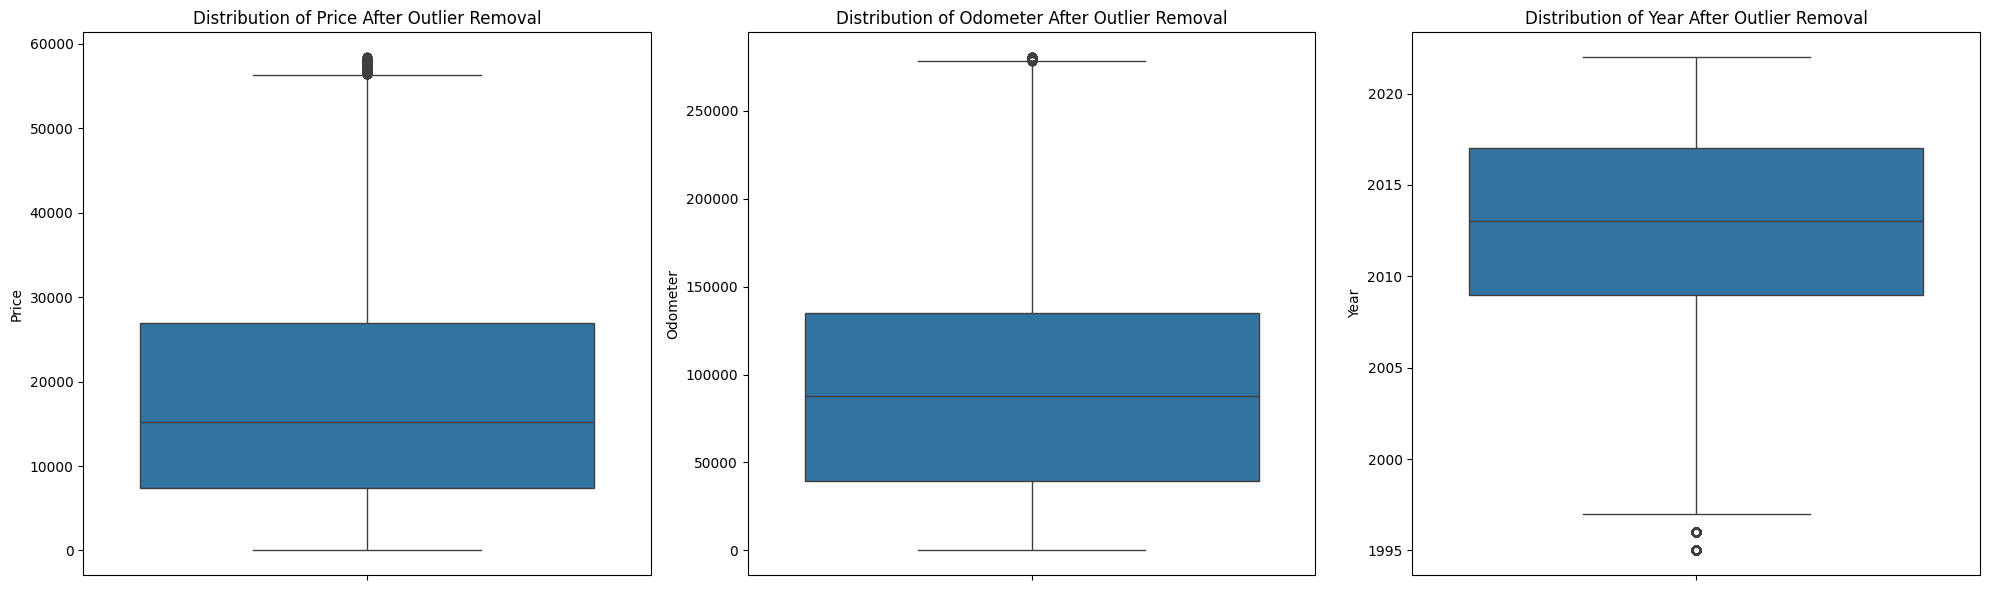

In [186]:
#Step 2.3 - Visualize the box plots for 'price', 'odometer', and 'year'
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Box plot for 'price'
sns.boxplot(y=df_cleaned_final['price'], ax=axes[0])
axes[0].set_title('Distribution of Price After Outlier Removal')
axes[0].set_ylabel('Price')

# Box plot for 'odometer'
sns.boxplot(y=df_cleaned_final['odometer'], ax=axes[1])
axes[1].set_title('Distribution of Odometer After Outlier Removal')
axes[1].set_ylabel('Odometer')

# Box plot for 'year'
sns.boxplot(y=df_cleaned_final['year'], ax=axes[2])
axes[2].set_title('Distribution of Year After Outlier Removal')
axes[2].set_ylabel('Year')

plt.tight_layout()
plt.show()

Step 3 - Visualize the final data frame

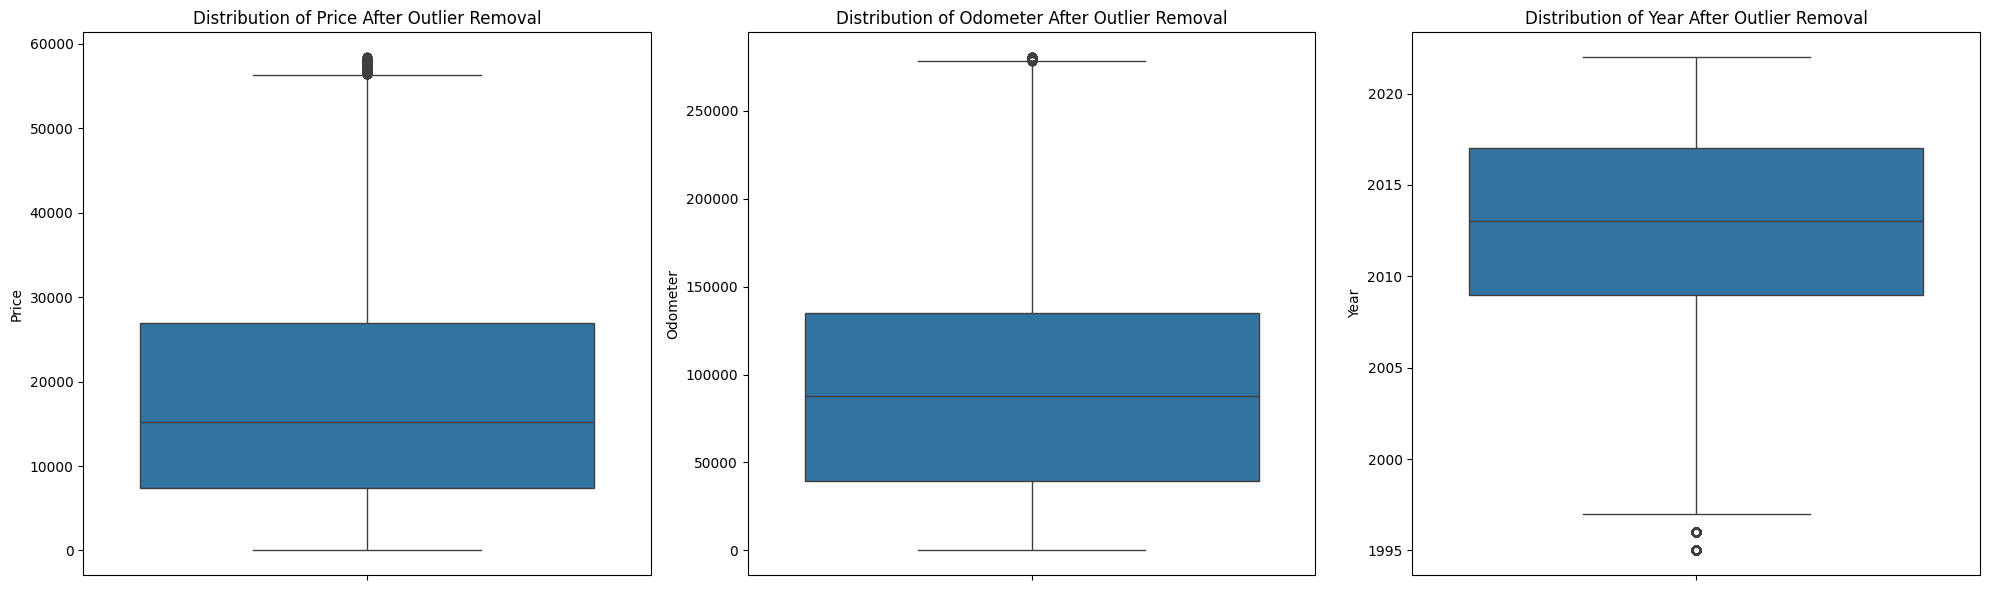

In [187]:
#Step 3.1 - Visualize the Numerical Columns
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Box plot for 'price'
sns.boxplot(y=df_cleaned_final['price'], ax=axes[0])
axes[0].set_title('Distribution of Price After Outlier Removal')
axes[0].set_ylabel('Price')

# Box plot for 'odometer'
sns.boxplot(y=df_cleaned_final['odometer'], ax=axes[1])
axes[1].set_title('Distribution of Odometer After Outlier Removal')
axes[1].set_ylabel('Odometer')

# Box plot for 'year'
sns.boxplot(y=df_cleaned_final['year'], ax=axes[2])
axes[2].set_title('Distribution of Year After Outlier Removal')
axes[2].set_ylabel('Year')

plt.tight_layout()
plt.show()

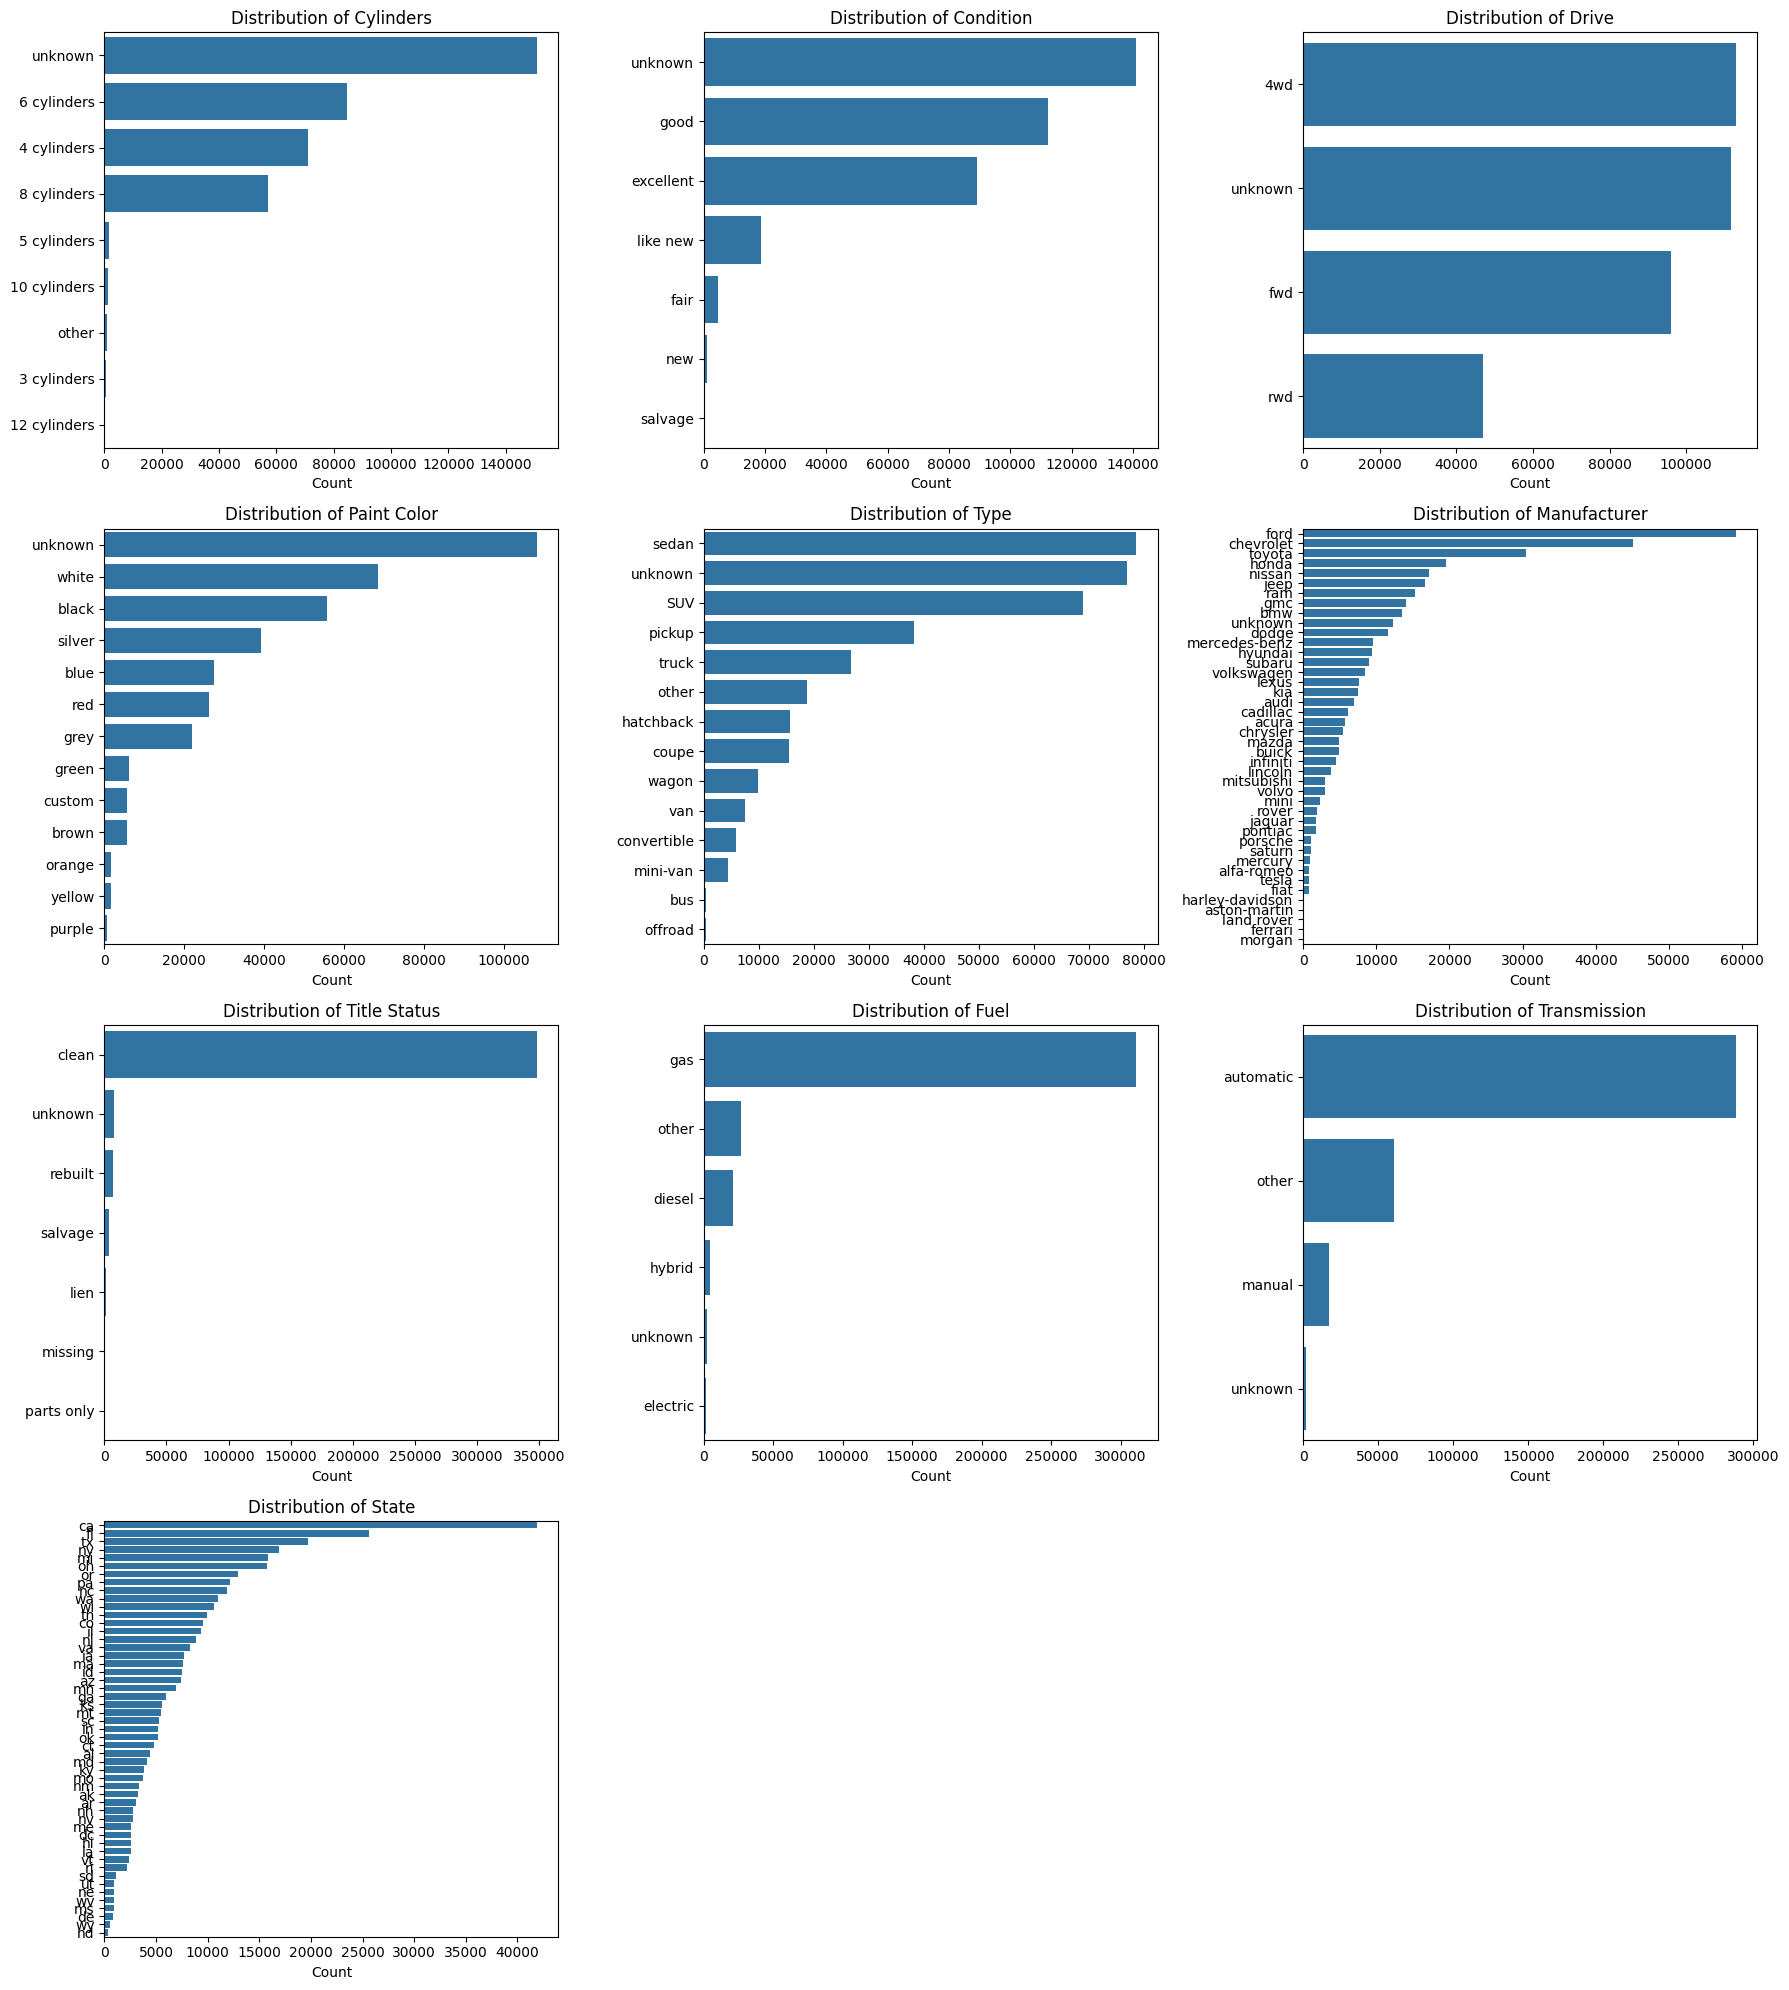

In [188]:
#Step 3.2 - Visualize categorical columns
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'cylinders', 'condition', 'drive', 'paint_color', 'type',
    'manufacturer', 'title_status', 'fuel', 'transmission', 'state',
]

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df_cleaned_final.columns:
        sns.countplot(y=df_cleaned_final[col], ax=axes[i], order=df_cleaned_final[col].value_counts().index)
        axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('')
    else:
        fig.delaxes(axes[i])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Step 4 - Encode the categorical data

In [189]:
# Identify categorical columns for one-hot encoding
categorical_cols = df_cleaned_final.select_dtypes(include='object').columns

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_cleaned_final, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame before encoding:", df_cleaned_final.shape)
print("Shape of DataFrame after encoding:", df_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
display(df_encoded.head())


Shape of DataFrame before encoding: (367783, 13)
Shape of DataFrame after encoding: (367783, 150)

First 5 rows of the encoded DataFrame:


,price,year,odometer,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
0,6000,2013,85548,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,11900,2013,85548,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,21000,2013,85548,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1500,2013,85548,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4900,2013,85548,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Step 5 - Normalize the numerical columns

In [190]:
#Step 5.1: Normalize the numerical columns - Price, Odometer, and Year

from sklearn.preprocessing import StandardScaler

numerical_cols_to_normalize = ['price', 'odometer', 'year']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply Standard Scaling to the selected numerical columns
df_encoded[numerical_cols_to_normalize] = scaler.fit_transform(df_encoded[numerical_cols_to_normalize])

Step 6: Prepare for modeling by splitting the dataframe into Testing set and Training set

In [191]:
#Step 6.1 - Split the dataset into 80% Training and 20% testing sets
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (294226, 149)
Shape of X_test: (73557, 149)
Shape of y_train: (294226,)
Shape of y_test: (73557,)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Step 1: Train a Linear regression model

In [192]:
#Step 1: Train & Tune Linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression R-squared: {r2:.4f}")
print(f"Linear Regression Mean Squared Error: {mse:.4f}")

Linear Regression R-squared: 0.6540
Linear Regression Mean Squared Error: 0.3446


Step 2: Train a Lasso Regression model and tune the hyperparameters with GridsearchCV

In [193]:
#Step 2: Train & Tune Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Instantiate Lasso model
lasso = Lasso(random_state=42, max_iter=2000)

# 2. Define param_grid for alpha
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

# 3. Initialize GridSearchCV
grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# 4. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 5. Retrieve the best Lasso model
best_lasso_model = grid_search.best_estimator_

print(f"Best Lasso alpha: {grid_search.best_params_['alpha']:.4f}")

# 6. Make predictions on the test set with the best model
y_pred_lasso = best_lasso_model.predict(X_test)

# 7. Calculate R-squared score
r2_lasso = r2_score(y_test, y_pred_lasso)

# 8. Calculate Mean Squared Error
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Best Lasso R-squared: {r2_lasso:.4f}")
print(f"Best Lasso Mean Squared Error: {mse_lasso:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Lasso alpha: 0.0001
Best Lasso R-squared: 0.6536
Best Lasso Mean Squared Error: 0.3451


Step 3: Train a Ridge Regression model and tune the hyperparameters with GridsearchCV

In [194]:
#Step 3: Train & Tune ridge regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Instantiate Ridge model
ridge = Ridge(random_state=42)

# 2. Define param_grid for alpha
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

# 3. Initialize GridSearchCV
grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# 4. Fit GridSearchCV to the training data
grid_search_ridge.fit(X_train, y_train)

# 5. Retrieve the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

print(f"Best Ridge alpha: {grid_search_ridge.best_params_['alpha']:.4f}")

# 6. Make predictions on the test set with the best model
y_pred_ridge = best_ridge_model.predict(X_test)

# 7. Calculate R-squared score
r2_ridge = r2_score(y_test, y_pred_ridge)

# 8. Calculate Mean Squared Error
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Best Ridge R-squared: {r2_ridge:.4f}")
print(f"Best Ridge Mean Squared Error: {mse_ridge:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Ridge alpha: 1.0000
Best Ridge R-squared: 0.6540
Best Ridge Mean Squared Error: 0.3446


Step 4: Compare model performance

In [195]:
#Step 4: Model performance comparison

# Create a dictionary to store the performance metrics
performance_metrics = {
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'R-squared': [r2, r2_lasso, r2_ridge],
    'Mean Squared Error': [mse, mse_lasso, mse_ridge]
}

# Convert the dictionary to a DataFrame
performance_df = pd.DataFrame(performance_metrics)

# Print the comparison table
print("\nModel Performance Comparison:")
print(performance_df.to_string(index=False))


Model Performance Comparison:
            Model  R-squared  Mean Squared Error
Linear Regression   0.653994            0.344649
 Lasso Regression   0.653581            0.345060
 Ridge Regression   0.654031            0.344612


Step 5: Extract the coefficients from the ridge model (Best model)

In [196]:
# Extract coefficients from the best Ridge model
coefficients = best_ridge_model.coef_
feature_names = X_train.columns

# Create a DataFrame to store coefficients
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort coefficients by their absolute value in descending order
coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("\nTop 10 Features with Highest Positive Coefficients:")
print(coefficients_df.head(10).to_string(index=False))

print("\nTop 10 Features with Highest Negative Coefficients:")
print(coefficients_df.tail(10).to_string(index=False))


Top 10 Features with Highest Positive Coefficients:
               Feature  Coefficient
  manufacturer_ferrari    -1.869378
         fuel_electric    -1.135981
           fuel_hybrid    -0.997396
              fuel_gas    -0.943344
    manufacturer_tesla     0.936485
            fuel_other    -0.850600
          fuel_unknown    -0.754782
cylinders_12 cylinders     0.746767
     manufacturer_fiat    -0.720217
  manufacturer_porsche     0.651664

Top 10 Features with Highest Negative Coefficients:
                  Feature  Coefficient
                 state_ut    -0.014362
        paint_color_green     0.013776
     manufacturer_lincoln     0.011277
manufacturer_aston-martin    -0.010433
       paint_color_yellow     0.010173
       manufacturer_volvo     0.008468
        paint_color_white    -0.008161
        title_status_lien     0.004533
         manufacturer_gmc    -0.004299
    manufacturer_cadillac     0.000652


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Evaluation Metric:**
- We will consider R-Squared and Mean-Squared-Error as the evalutation metric.
- R-squared providers the accuracy percentage
- Mean-square tells us how far are we from the correct prediction.

**Summary of evaluation:**
- Among Linear regression, Lasso regression and Ridge regression, **Ridge Regression** had the highest R-Square value (0.654031) and lowest mean-squared error (0.344612)
- Based on the R-Square model, we know our model can predict the price with ~65% accuracy

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### Business Question Overview

The core business challenge is to determine the main factors influencing used car prices. This can be conceptualized as a supervised machine learning regression task. Our objective is to develop a predictive model that estimates a used car's price using a variety of features, including its make, model, year, mileage, condition, and other pertinent characteristics. The model's effectiveness will be measured by how accurately it can forecast car prices and pinpoint the most significant features that drive those prices.



#### Research Question
What drives the price of a used car?


#### Data Sources
[Modified dataset from Kaggle] (vehicles.csv)


#### Methodology
Using the CRISP-DM Methodology, the predictive model uses the below methods:
- Data Understanding
  * Identify missing values
  * Identify duplicate rows
  * Identify the type of information in each column
- Data Preparation
  * Clean dataset
    - Drop Cols (vin, size, id, region, model)
    - Categorial Cols (cylinders, condition, drive, paint_color, type, manufacturer, title_status, fuel, and transmission)
    - Replace missing values with 'unknown' to retain information in other columns
    - Numerical Cols (Odometer & Year) - Replace the missing values with the column median
    - Convert cols "Year" and "Odometer" to integers for easier processing
    - Remove rows where the value is "Zero" in the price column
  * Outlier Analysis
    - Remove outliers from Price, Odometer and year
  * Visualization
    - Visualize the Numerical Columns
    - Visualize categorical columns
  * Encode the categorical data
  * Normalize the numerical columns
  * Split the dataframe into Testing set and Training set
- Modeling
  * Train a Linear regression model
  * Train a Lasso Regression model and tune the hyperparameters with GridsearchCV
  * Train a Ridge Regression model and tune the hyperparameters with GridsearchCV
  * Compare model performance
  * Extract the coefficients from the ridge model (Best model)


**Key Results**

Based on the analysis of key feature importances from the Ridge Regression model, here are actionable recommendations:

1. Focus on acquiring vehicles that historically command higher prices. Specifically, target Tesla vehicles (showed the strongest positive impact on price). This indicates a high demand and willingness to pay a premium for Tesla cars. Dealerships should actively seek out used Teslas.
2. Cars with cylinders_12 cylinders also significantly contribute to higher prices, likely due to their luxury or high-performance appeal. These should be considered for high-end inventory.
3. Re-evaluate Rare Luxury Brands: The strong negative coefficients for Ferrari and Morgan are counter-intuitive. This could point to data issues (sparse data, outliers, or misclassification) or a very specific niche market that the general model doesn't capture well. Dealers should conduct separate, in-depth market research for these ultra-luxury brands before making inventory decisions, rather than relying solely on this model's coefficient.
4. Be cautious with brands like Fiat which showed a notable negative impact on price. While they might attract a specific segment, they are less likely to yield high returns.
5. For vehicles with high positive coefficients (e.g., Teslas, 12-cylinder cars), dealerships can set more aggressive pricing, knowing the market supports a premium.

**Next Steps:**
- Assess the model with excluded columns such as "Model" and "Region" to drive deeper insights
- Run advanced modeling techniques such as "Random Forest" to further evaluate the problem.